# Differential expression on GSE50760 (colorectal cancer)

Stage 1 of `omics-rag-playground`: a real-data deliverable on top of the airway warm-up.

**Dataset.** GSE50760 (Kim et al. 2014): 18 colorectal cancer patients, three matched samples each — primary tumor, adjacent normal mucosa, and synchronous liver metastasis (54 samples total). Counts and metadata are pulled from [recount3](https://rna.recount.bio/), which provides uniformly re-processed RNA-seq quantifications.

**Structure of the analysis.** We approach the dataset twice, in increasing levels of sophistication, so that the value of each modeling choice can be quantified:

1. **First attempt — single-factor design `~condition`.** A naive baseline that ignores the paired study structure. We run two contrasts: tumor vs normal, and metastasis vs tumor. The first contrast yields biologically coherent results; the second is dominated by a tissue-identity confound that we document explicitly. Pathway enrichment is run on the tumor-vs-normal hits.

2. **Improved analysis — multi-factor design `~patient + condition`.** We re-fit DESeq2 with patient blocking, leveraging the paired structure of the data. We compare against the single-factor baseline to quantify the gain in statistical power, and re-run pathway enrichment on the patient-controlled DE set.

The two analyses are presented in parallel rather than the improved one replacing the baseline: keeping both makes the methodological comparison explicit and preserves a record of the analytical decisions.

In [1]:
import urllib.request
from pathlib import Path

import gseapy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

from omics_rag_playground.annotation import map_ensembl_to_symbol

## Data acquisition

Counts, sample metadata, and QC metrics are downloaded from recount3. Files are cached locally in `data/raw/` (gitignored). The gene annotation GTF is included for completeness, though we use `mygene.info` for ID-to-symbol mapping.

In [2]:
DATA_RAW = Path("../data/raw")

RECOUNT3_FILES = {
    "gene_sums": "https://duffel.rail.bio/recount3/human/data_sources/sra/gene_sums/80/SRP029880/sra.gene_sums.SRP029880.G026.gz",
    "proj_meta": "https://duffel.rail.bio/recount3/human/data_sources/sra/metadata/80/SRP029880/sra.sra.SRP029880.MD.gz",
    "recount_qc": "https://duffel.rail.bio/recount3/human/data_sources/sra/metadata/80/SRP029880/sra.recount_qc.SRP029880.MD.gz",
    "gene_annotation": "https://duffel.rail.bio/recount3/human/annotations/gene_sums/human.gene_sums.G026.gtf.gz",
}

for name, url in RECOUNT3_FILES.items():
    fname = url.split("/")[-1]
    fpath = DATA_RAW / fname
    if fpath.exists():
        print(f"✓ {name}: already exists ({fpath.name}, {fpath.stat().st_size / 1e6:.1f} MB)")
    else:
        print(f"↓ {name}: downloading {fname}...")
        urllib.request.urlretrieve(url, fpath)
        print(f"  done ({fpath.stat().st_size / 1e6:.1f} MB)")

✓ gene_sums: already exists (sra.gene_sums.SRP029880.G026.gz, 5.6 MB)
✓ proj_meta: already exists (sra.sra.SRP029880.MD.gz, 0.0 MB)
✓ recount_qc: already exists (sra.recount_qc.SRP029880.MD.gz, 0.0 MB)
✓ gene_annotation: already exists (human.gene_sums.G026.gtf.gz, 1.8 MB)


In [3]:
metadata = pd.read_csv(DATA_RAW / "sra.sra.SRP029880.MD.gz", sep="\t", comment="#", index_col=0)
counts_df = (
    pd.read_csv(DATA_RAW / "sra.gene_sums.SRP029880.G026.gz", sep="\t", comment="#", index_col=0)
    .T
)
qc = pd.read_csv(DATA_RAW / "sra.recount_qc.SRP029880.MD.gz", sep="\t", index_col=0)

print(f"Counts shape: {counts_df.shape} (samples x genes)")
print(f"Metadata shape: {metadata.shape}")
print(f"QC shape: {qc.shape}")

Counts shape: (54, 63856) (samples x genes)
Metadata shape: (54, 40)
QC shape: (54, 111)


### Index alignment

PyDESeq2 requires `counts` (samples × genes) and `metadata` to share an identical index. We sort all three frames on the SRA run accession (`external_id`) and verify alignment.

In [4]:
counts_df = counts_df.sort_index()
metadata = metadata.set_index("external_id")
qc = qc.set_index("external_id")

assert (counts_df.index == metadata.index).all(), "counts/metadata index mismatch"
assert (counts_df.index == qc.index).all(), "counts/qc index mismatch"
print("All indices aligned (n=54).")

All indices aligned (n=54).


### Coverage-to-counts conversion

recount3 distributes per-gene **coverage sums** (sum of base-level coverage over each gene), not raw read counts. PyDESeq2 expects integer read counts, and the magnitude difference (~10²-10³ fold) destabilizes downstream steps such as LFC shrinkage. We convert via the canonical formula:

$$\text{read\_count} \approx \frac{\text{coverage\_sum}}{\text{average mapped read length}}$$

Average mapped length per sample is taken from the recount3 QC metadata (`star.average_mapped_length`).

In [5]:
read_lengths = qc.loc[counts_df.index, "star.average_mapped_length"]
counts_df = counts_df.div(read_lengths, axis=0).round().astype(int)

print(f"Average read length range: {read_lengths.min():.1f} - {read_lengths.max():.1f}")
print(f"Counts after conversion (max value): {counts_df.values.max():,}")

Average read length range: 197.3 - 199.1
Counts after conversion (max value): 2,994,461


### Sample metadata parsing

The biologically informative metadata (tissue type, AJCC stage, etc.) lives inside the `sample_attributes` column as a single delimited string per sample. We parse it into separate columns and standardize the tissue label into a clean `condition` factor with three levels: `tumor`, `normal`, `metastasis`. The patient identifier is extracted later, when we move to the multi-factor analysis.

In [6]:
def parse_attrs(s: str) -> dict:
    """Parse a recount3 `sample_attributes` string into a flat dict.

    The string format is `key1;;value1|key2;;value2|...`.
    """
    if not isinstance(s, str):
        return {}
    result = {}
    for field in s.split("|"):
        if ";;" not in field:
            continue
        key, value = field.split(";;", 1)
        result[key.strip()] = value.strip()
    return result


def standardize_tissue(t: str) -> str:
    """Map free-text tissue descriptions onto a clean three-level factor."""
    t = t.lower()
    if "metasta" in t:
        return "metastasis"
    if "normal" in t:
        return "normal"
    if "tumor" in t or "cancer" in t or "primary" in t:
        return "tumor"
    return "unknown"


parsed = metadata["sample_attributes"].apply(parse_attrs).apply(pd.Series)
parsed.columns = [c.replace(" ", "_").lower() for c in parsed.columns]
metadata = pd.concat([metadata, parsed], axis=1)
metadata["condition"] = metadata["tissue"].apply(standardize_tissue)

print(metadata["condition"].value_counts())

condition
tumor         18
normal        18
metastasis    18
Name: count, dtype: int64


### Filtering

Standard low-count filtering: drop genes with fewer than 10 total reads across all samples. No samples are dropped (all 54 have a valid `condition`).

In [7]:
samples_to_keep = ~metadata["condition"].isna()
counts_df = counts_df.loc[samples_to_keep]
metadata = metadata.loc[samples_to_keep]
print(f"Samples kept: {samples_to_keep.sum()}/{len(samples_to_keep)}")

genes_to_keep = counts_df.columns[counts_df.sum(axis=0) >= 10]
counts_df = counts_df[genes_to_keep]
print(f"Genes kept: {len(genes_to_keep):,} (low-count threshold: rowSum >= 10)")

Samples kept: 54/54
Genes kept: 36,038 (low-count threshold: rowSum >= 10)


## First attempt: single-factor design `~condition`

We start with the simplest possible model, treating `condition` (tumor / normal / metastasis) as the only explanatory factor. The patient covariate is intentionally ignored at this stage: this baseline establishes a reference against which the improved patient-blocked design can later be compared.

### DESeq2 fit

In [8]:
dds = DeseqDataSet(
    counts=counts_df,
    metadata=metadata,
    design="~condition",
    refit_cooks=True,
)
dds.deseq2()

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.04 seconds.

Fitting dispersions...
... done in 2.56 seconds.

Fitting dispersion trend curve...
... done in 0.26 seconds.

Fitting MAP dispersions...
... done in 3.44 seconds.

Fitting LFCs...
... done in 1.88 seconds.

Calculating cook's distance...
... done in 0.06 seconds.

Replacing 1100 outlier genes.

Fitting dispersions...
... done in 0.10 seconds.

Fitting MAP dispersions...
... done in 0.10 seconds.

Fitting LFCs...
... done in 0.07 seconds.



**A note on LFC shrinkage.** For this dataset, calling `lfc_shrink()` triggers numerical instability (`RuntimeWarning: overflow encountered in exp`) and collapses many estimates to ~0, while leaving a handful of large-effect genes untouched. This is a known issue with apeglm-style prior fitting on cancer datasets where the LFC distribution is broad and bimodal. With 18 replicates per condition the unshrunk Wald-test LFCs are already well-conditioned, so we proceed with them and document the choice.

### Patient extraction and design integrity

The patient identifier is encoded in the recount3 `experiment_title` column with the pattern `AMC_<NN>` (AMC = Asan Medical Center, the institution that contributed the dataset). We extract it with a regex and verify that every (patient, condition) pair occurs exactly once.

In [9]:
metadata["patient"] = "P" + metadata["experiment_title"].str.extract(r"AMC_(\d+)")[0]

design_check = metadata.groupby(["patient", "condition"]).size().unstack(fill_value=0)
print("Design balance (rows: patient, columns: condition):")
print(design_check)
print(f"\nFully balanced 18×3 design: {(design_check == 1).all().all()}")

Design balance (rows: patient, columns: condition):
condition  metastasis  normal  tumor
patient                             
P10                 1       1      1
P12                 1       1      1
P13                 1       1      1
P17                 1       1      1
P18                 1       1      1
P19                 1       1      1
P2                  1       1      1
P20                 1       1      1
P21                 1       1      1
P22                 1       1      1
P23                 1       1      1
P24                 1       1      1
P3                  1       1      1
P5                  1       1      1
P6                  1       1      1
P7                  1       1      1
P8                  1       1      1
P9                  1       1      1

Fully balanced 18×3 design: True


### Exploratory analysis: PCA

In [10]:
dds.vst()
vst_counts = dds.layers["vst_counts"]

Fit type used for VST : parametric
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.06 seconds.

Fitting dispersions...
... done in 2.58 seconds.



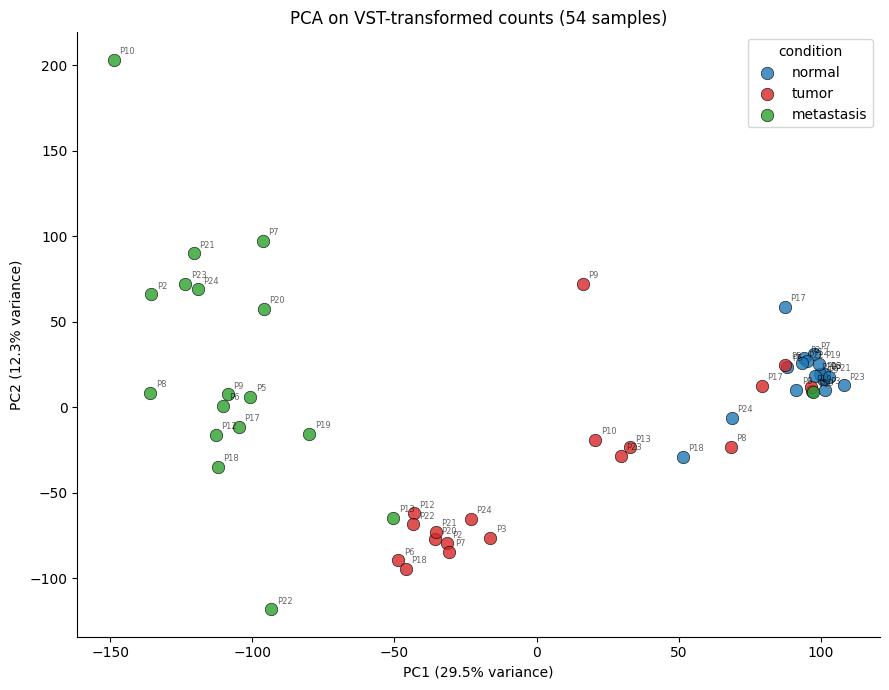

In [11]:


pca = PCA(n_components=2)
coords = pca.fit_transform(vst_counts)

# DataFrame per facilitare il plotting con seaborn-like API
pca_df = pd.DataFrame({
    "PC1": coords[:, 0],
    "PC2": coords[:, 1],
    "condition": metadata["condition"].values,
    "patient": metadata["patient"].values,
})

# Plot: color = condition, marker shape = patient
fig, ax = plt.subplots(figsize=(9, 7))
condition_colors = {"normal": "#1f77b4", "tumor": "#d62728", "metastasis": "#2ca02c"}

# Con 18 patient, 18 marker shape è troppo. Soluzione: mostra solo color
# per condition e ignora patient nello shape (oppure usa numeri come label)
for cond, color in condition_colors.items():
    mask = pca_df["condition"] == cond
    ax.scatter(
        pca_df.loc[mask, "PC1"],
        pca_df.loc[mask, "PC2"],
        s=80, c=color, alpha=0.8, edgecolor="k", linewidth=0.5,
        label=cond,
    )

# Optional: annotate with patient ID for traceability
for _, row in pca_df.iterrows():
    ax.annotate(
        str(row["patient"]),
        (row["PC1"], row["PC2"]),
        fontsize=6, alpha=0.6,
        xytext=(4, 4), textcoords="offset points",
    )

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title("PCA on VST-transformed counts (54 samples)")
ax.legend(title="condition")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
# plt.savefig("../docs/img/pca_gse50760.png", dpi=150, bbox_inches="tight")
plt.show()

**PCA on VST-transformed counts** reveals two dominant axes of variation:

- **PC1 (29.5% variance)** separates samples by **tissue of origin**: 
  the right-hand cluster contains all normal mucosa and most primary 
  tumor samples (both colon-derived), while metastases are pushed to 
  the left/centre — they are biopsied from liver. PC1 is therefore 
  dominated by tissue identity, mirroring the liver-tissue confound 
  identified in the metastasis-vs-tumor DE analysis below.

- **PC2 (12.3% variance)** captures more subtle, inter-individual 
  variation that does not align cleanly with condition. A few 
  patient-level outliers are visible: P10 has a very atypical 
  metastasis profile (PC2 ≈ +200), and several primary tumors 
  (P10, P9, P12, P18, P22) sit below the colon cluster, possibly 
  reflecting variation in tumor cellularity or molecular subtype.

Crucially, **tumor and normal samples overlap substantially within 
the colon cluster on the right**: the tumor-vs-normal axis is not 
captured by either of the first two principal components. The 
biological difference exists but is small relative to inter-patient 
variability and the dominant tissue-identity axis. This is the 
quantitative motivation for two analytical choices made later in 
the notebook:

1. The multi-factor design `~patient + condition` controls for the 
   patient-level variability on PC2 and beyond, recovering ~2,200 
   additional DE genes by absorbing the inter-individual variance 
   into a separate model term.
2. The metastasis-vs-tumor contrast is dominated by PC1 (tissue 
   identity), making it scientifically uninformative for 
   metastasis-intrinsic biology — as confirmed by the gene-level 
   results.

Tracing same-patient triplets across the plot (e.g. P22's three 
samples in the lower-left, P17's two tumors near the colon cluster 
with metastasis at PC1 ≈ -110) gives an intuitive feel for the 
paired

### Tumor vs normal — contrast and gene-level results

In [12]:
stats_tn = DeseqStats(dds, contrast=["condition", "tumor", "normal"])
stats_tn.summary()

results_tn = stats_tn.results_df.copy()

Running Wald tests...


Log2 fold change & Wald test p-value: condition tumor vs normal
                     baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene_id                                                                       
ENSG00000223972.5    0.794806       -0.429628  0.595181 -0.721843  0.470391   
ENSG00000278267.1    7.298400        0.176701  0.272428  0.648616  0.516587   
ENSG00000227232.5  256.463255       -0.148196  0.162318 -0.912999  0.361243   
ENSG00000243485.5    1.487543        0.627079  0.529344  1.184633  0.236163   
ENSG00000239945.1    6.057448       -0.185858  0.293718 -0.632776  0.526880   
...                       ...             ...       ...       ...       ...   
ENSG00000235412.1    0.430927       -1.058310  0.827151 -1.279464  0.200734   
ENSG00000228786.5    0.253059       -0.072234  1.094771 -0.065981  0.947393   
ENSG00000229238.3    0.616014       -0.651389  0.968640 -0.672478  0.501280   
ENSG00000231514.1    0.315978        0.980291  0.946325  1.035892  

... done in 0.63 seconds.



**Annotation: Ensembl gene IDs to HGNC symbols.** `map_ensembl_to_symbol` (in `omics_rag_playground.annotation`) wraps `mygene.info` with on-disk caching and transparent handling of versioned Ensembl IDs (`ENSGxxxxxxx.N`).

In [13]:
CACHE_PATH = Path("../data/processed/ensembl_symbol_cache.json")

results_tn["symbol"] = map_ensembl_to_symbol(results_tn.index, cache_path=CACHE_PATH)

n_mapped = results_tn["symbol"].notna().sum()
print(f"Mapped {n_mapped:,}/{len(results_tn):,} genes ({100 * n_mapped / len(results_tn):.1f}%)")

Mapped 28,855/36,038 genes (80.1%)


In [14]:
n_sig_tn = (results_tn["padj"] < 0.05).sum()
print(f"Significant DE genes (padj < 0.05): {n_sig_tn:,}")

top_by_padj_tn = results_tn.sort_values("padj").head(20)
print(top_by_padj_tn[["symbol", "baseMean", "log2FoldChange", "padj"]])

Significant DE genes (padj < 0.05): 9,303
                       symbol     baseMean  log2FoldChange          padj
gene_id                                                                 
ENSG00000122641.10      INHBA   534.181036        4.934186  4.016841e-22
ENSG00000175832.12       ETV4   979.911994        4.186943  9.328363e-22
ENSG00000060718.20    COL11A1   403.304708        5.385960  9.328363e-22
ENSG00000148848.14     ADAM12   255.452107        4.149736  1.262644e-21
ENSG00000123500.9     COL10A1   238.208388        6.508386  2.640040e-20
ENSG00000163347.5       CLDN1  1402.617199        4.082611  1.181994e-18
ENSG00000078098.13        FAP   211.555867        3.908934  1.164156e-17
ENSG00000151388.10   ADAMTS12   322.390310        3.311544  1.875033e-17
ENSG00000164932.12     CTHRC1   410.362536        3.917084  2.134506e-17
ENSG00000142539.9        None   431.405206       -2.633903  3.690049e-17
ENSG00000196611.4        MMP1   647.228418        5.110038  4.510655e-16
ENSG00000

**Biological sanity check.** The top 20 hits are dominated by stromal/EMT and ECM-remodeling markers well known in colorectal cancer: collagens (COL11A1, COL10A1), inhibin βA (INHBA), fibroblast activation protein (FAP), matrix metalloproteinase MMP1, ADAMs/ADAMTS proteases, CTHRC1, CEMIP, and Wnt-pathway WNT2. This signature reflects both tumor-intrinsic invasive programs and the recruited cancer-associated fibroblast compartment. The pipeline is producing biologically coherent results.

Notably, the single-factor model's top hits are almost entirely **upregulated** in tumor — these are genes essentially absent from normal mucosa, hence with very low inter-patient variability. The downregulated side of the picture is muted here. As we will see, patient blocking changes this substantially.

### Tumor vs normal — volcano plot

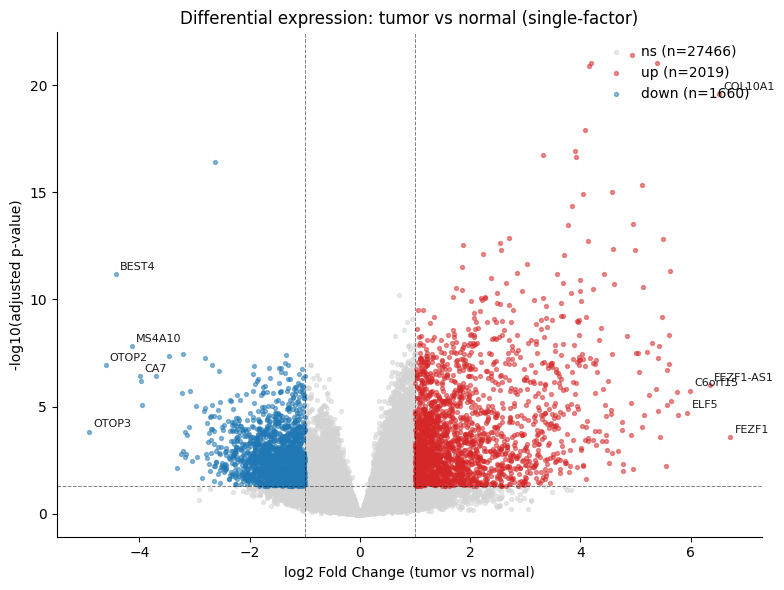

In [15]:
LFC_THRESHOLD = 1.0     # |log2FC| > 1, i.e. fold change > 2x
PADJ_THRESHOLD = 0.05   # FDR < 5%


def volcano_plot(results: pd.DataFrame, title: str, xlabel: str) -> None:
    """Render a volcano plot with the top 5 up- and 5 down-regulated genes annotated."""
    df = results.dropna(subset=["padj"]).copy()
    df["neg_log10_padj"] = -np.log10(df["padj"])

    df["category"] = "ns"
    df.loc[(df["padj"] < PADJ_THRESHOLD) & (df["log2FoldChange"] > LFC_THRESHOLD), "category"] = "up"
    df.loc[(df["padj"] < PADJ_THRESHOLD) & (df["log2FoldChange"] < -LFC_THRESHOLD), "category"] = "down"

    colors = {"ns": "lightgray", "up": "#d62728", "down": "#1f77b4"}

    fig, ax = plt.subplots(figsize=(8, 6))
    for cat, color in colors.items():
        sub = df[df["category"] == cat]
        ax.scatter(
            sub["log2FoldChange"], sub["neg_log10_padj"],
            s=8, alpha=0.5, c=color, label=f"{cat} (n={len(sub)})",
        )

    sig_mapped = df[(df["padj"] < PADJ_THRESHOLD) & df["symbol"].notna()]
    to_annotate = pd.concat([
        sig_mapped.nlargest(5, "log2FoldChange"),
        sig_mapped.nsmallest(5, "log2FoldChange"),
    ])
    for _, row in to_annotate.iterrows():
        ax.annotate(
            row["symbol"],
            (row["log2FoldChange"], row["neg_log10_padj"]),
            fontsize=8, alpha=0.9,
            xytext=(3, 3), textcoords="offset points",
        )

    ax.axhline(-np.log10(PADJ_THRESHOLD), ls="--", c="black", lw=0.7, alpha=0.5)
    ax.axvline(LFC_THRESHOLD, ls="--", c="black", lw=0.7, alpha=0.5)
    ax.axvline(-LFC_THRESHOLD, ls="--", c="black", lw=0.7, alpha=0.5)

    ax.set_xlabel(xlabel)
    ax.set_ylabel("-log10(adjusted p-value)")
    ax.set_title(title)
    ax.legend(loc="upper right", frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()


volcano_plot(
    results_tn,
    title="Differential expression: tumor vs normal (single-factor)",
    xlabel="log2 Fold Change (tumor vs normal)",
)

### Metastasis vs tumor — a worked example of confound detection

We reuse the same fitted `DeseqDataSet` and just request a different contrast. The Wald test is recomputed; everything else (size factors, dispersions, LFCs) stays the same.

In [16]:
stats_mt = DeseqStats(dds, contrast=["condition", "metastasis", "tumor"])
stats_mt.summary()

results_mt = stats_mt.results_df.copy()
results_mt["symbol"] = map_ensembl_to_symbol(results_mt.index, cache_path=CACHE_PATH)

n_sig_mt = (results_mt["padj"] < 0.05).sum()
print(f"Significant DE genes (padj < 0.05): {n_sig_mt:,}")

top_by_padj_mt = results_mt.sort_values("padj").head(20)
print(top_by_padj_mt[["symbol", "baseMean", "log2FoldChange", "padj"]])

Running Wald tests...


Log2 fold change & Wald test p-value: condition metastasis vs tumor
                     baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene_id                                                                       
ENSG00000223972.5    0.794806       -0.457244  0.662874 -0.689790  0.490326   
ENSG00000278267.1    7.298400        0.080370  0.264696  0.303633  0.761407   
ENSG00000227232.5  256.463255        0.046833  0.162348  0.288474  0.772984   
ENSG00000243485.5    1.487543        0.544555  0.452195  1.204248  0.228494   
ENSG00000239945.1    6.057448        0.176975  0.291672  0.606761  0.544009   
...                       ...             ...       ...       ...       ...   
ENSG00000235412.1    0.430927       -0.176933  0.934123 -0.189410  0.849771   
ENSG00000228786.5    0.253059       -0.026542  1.094065 -0.024260  0.980645   
ENSG00000229238.3    0.616014       -0.879552  1.077515 -0.816278  0.414341   
ENSG00000231514.1    0.315978       -1.399666  0.994429 -1.4075

... done in 0.58 seconds.



**Liver tissue identity dominates this contrast.** The top hits (CYP2E1, CRP, HPX, APOH, FGL1, HP, ORM1, fibrinogen subunits FGA/B/G, apolipoproteins APOA1/B/C3, antithrombin SERPINC1, GC, AMBP, ...) are all canonical hepatocyte markers, with LFC ~9-10 and padj < 1e-65. These are not metastasis effectors: they are the transcriptional fingerprint of liver tissue itself.

Inspecting deeper into the ranked list (verified manually during analysis) reveals a long "second wave" of liver-enriched transcripts — hepcidin (HAMP), ceruloplasmin (CP), liver-specific lectins (MBL2, MASP2, COLEC10/11), liver enzymes (HAO1/2, GYS2, FTCD, G6PC1), and additional plasma proteins. Filtering against curated lists of known liver markers does not recover a tumor-intrinsic metastatic signal: hepatocyte transcripts continue to dominate.

**Why.** Metastasis biopsies in this study are tissue-level extractions from liver, in which hepatocyte transcripts vastly outnumber tumor-cell transcripts. The bulk DE contrast therefore reflects tissue identity ("liver vs colon") more than metastasis-intrinsic biology ("metastatic tumor cells vs primary tumor cells").

**Implications.**
- Bulk RNA-seq is poorly suited for probing metastasis-specific signaling (EMT, niche adaptation, liver-tropism programs) in this study design. Single-cell RNA-seq or computational deconvolution would be required.
- The tumor-vs-normal contrast above is *not* affected by this confound (both groups are sampled from colon tissue) and remains the scientifically valid target for downstream pathway enrichment.

We retain this section as a worked example of confound detection in a public RNA-seq dataset, rather than as a basis for biological inference. The patient-blocked re-analysis below also focuses on the tumor-vs-normal contrast for the same reason.

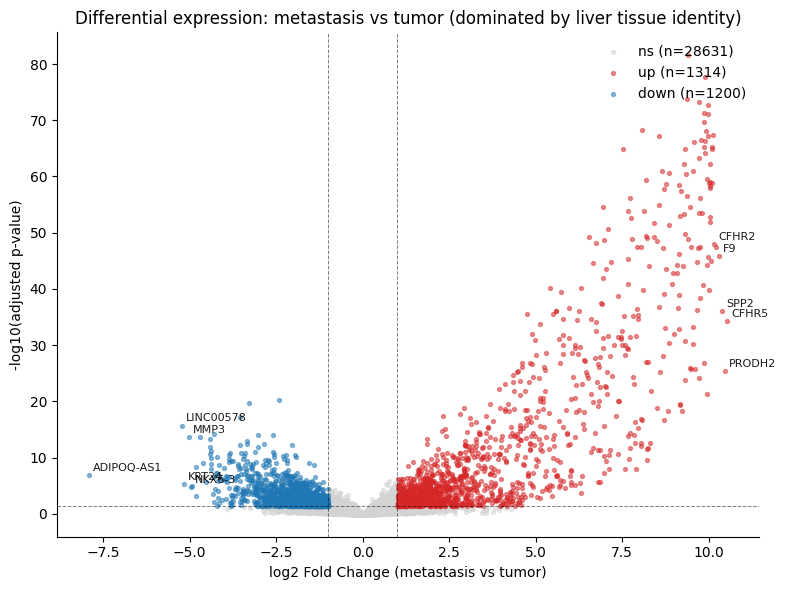

In [17]:
volcano_plot(
    results_mt,
    title="Differential expression: metastasis vs tumor (dominated by liver tissue identity)",
    xlabel="log2 Fold Change (metastasis vs tumor)",
)

### Pathway enrichment — single-factor tumor vs normal

We run over-representation analysis (ORA) with `gseapy.enrichr` against the **MSigDB Hallmarks 2020** collection (50 curated pathway-level gene sets). We test the up- and down-regulated DE gene lists separately.

Only the tumor-vs-normal contrast is used, since the metastasis-vs-tumor contrast is dominated by tissue contamination and would yield enrichment on "liver-specific" gene sets, which is not a biologically meaningful conclusion about metastasis.

In [18]:
de_up_sf = (
    results_tn[(results_tn["padj"] < 0.05) & (results_tn["log2FoldChange"] > 1)]
    .dropna(subset=["symbol"])
    ["symbol"]
    .tolist()
)
de_down_sf = (
    results_tn[(results_tn["padj"] < 0.05) & (results_tn["log2FoldChange"] < -1)]
    .dropna(subset=["symbol"])
    ["symbol"]
    .tolist()
)

print(f"Single-factor — Upregulated (LFC > 1, padj < 0.05): {len(de_up_sf):,} genes")
print(f"Single-factor — Downregulated (LFC < -1, padj < 0.05): {len(de_down_sf):,} genes")

Single-factor — Upregulated (LFC > 1, padj < 0.05): 1,747 genes
Single-factor — Downregulated (LFC < -1, padj < 0.05): 1,412 genes


In [19]:
enr_up_sf = gseapy.enrichr(
    gene_list=de_up_sf,
    gene_sets="MSigDB_Hallmark_2020",
    organism="human",
    outdir=None,
)
enr_down_sf = gseapy.enrichr(
    gene_list=de_down_sf,
    gene_sets="MSigDB_Hallmark_2020",
    organism="human",
    outdir=None,
)

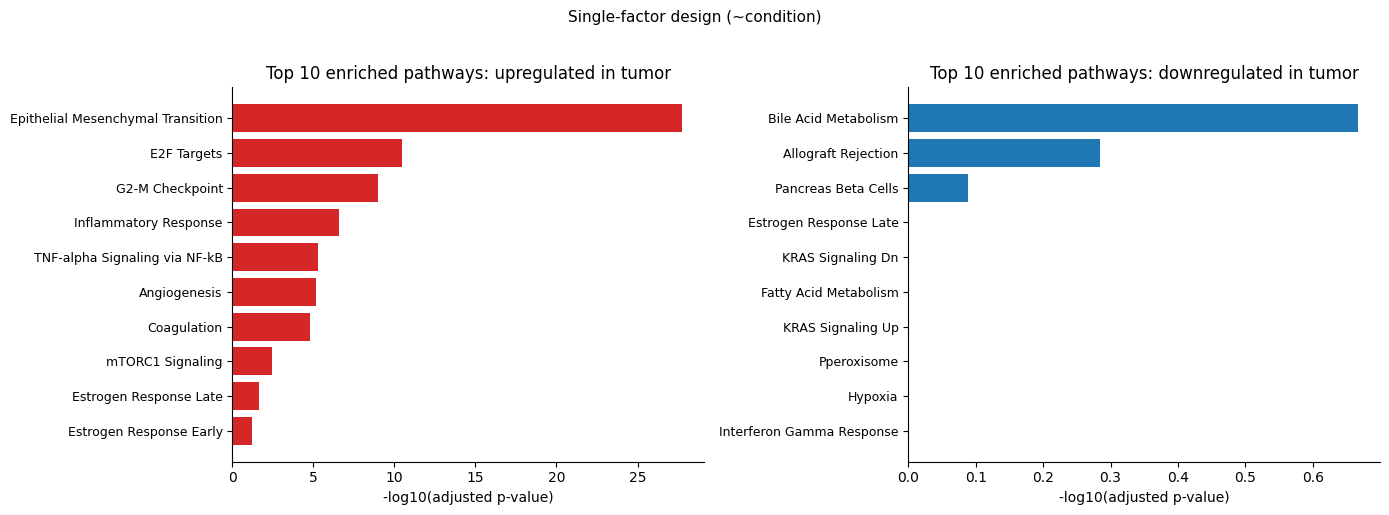

In [20]:
def plot_enrichment(enr_up, enr_down, suptitle: str | None = None) -> None:
    """Side-by-side bar plot of the top 10 enriched pathways for up- and down-regulated genes."""
    top10_up = enr_up.results.nsmallest(10, "Adjusted P-value")
    top10_down = enr_down.results.nsmallest(10, "Adjusted P-value")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    for ax, top, color, title in [
        (ax1, top10_up, "#d62728", "Top 10 enriched pathways: upregulated in tumor"),
        (ax2, top10_down, "#1f77b4", "Top 10 enriched pathways: downregulated in tumor"),
    ]:
        y_pos = np.arange(len(top))
        ax.barh(y_pos, -np.log10(top["Adjusted P-value"]), color=color)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(top["Term"], fontsize=9)
        ax.invert_yaxis()
        ax.set_xlabel("-log10(adjusted p-value)")
        ax.set_title(title)
        ax.spines[["top", "right"]].set_visible(False)

    if suptitle:
        fig.suptitle(suptitle, fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()


plot_enrichment(
    enr_up_sf, enr_down_sf,
    suptitle="Single-factor design (~condition)",
)

**Biological interpretation.** The single-factor enrichment recapitulates the canonical molecular phenotype of colorectal cancer:

- **Upregulated in tumor** — Epithelial-Mesenchymal Transition is the top hit (consistent with the stromal/ECM-remodeling signature observed at the gene level), followed by E2F Targets and G2-M Checkpoint (cell-cycle/proliferation), Inflammatory Response and TNF-α/NF-κB signaling (tumor microenvironment), Angiogenesis (tumor vasculature), and Coagulation (often co-active in invasive cancers).
- **Downregulated in tumor** — typically dominated by tissue-differentiation programs and oxidative metabolism, reflecting the dedifferentiation and Warburg-like metabolic shift characteristic of colon adenocarcinoma. This downregulated side, however, looks somewhat muted at this stage — many candidate genes are not significant under the simple model. We will see it sharpen substantially under patient blocking.

Together these signatures align with the established CRC molecular phenotype: dedifferentiation, proliferation, EMT, and microenvironment activation.

## Improved analysis: multi-factor design `~patient + condition`

**Rationale.** GSE50760 has a paired study design: every patient contributes three samples (tumor, normal, metastasis). The single-factor model `~condition` ignores this structure and treats inter-patient variability as residual noise, which inflates standard errors and reduces statistical power on the condition contrast. By adding a `patient` term to the design we let DESeq2 absorb that inter-individual variability into a separate component, freeing power for the contrast we actually care about.

**Structure.**

1. Re-fit DESeq2 with `design="~patient + condition"`.
2. Re-run the tumor-vs-normal contrast and compare against the single-factor baseline.
3. Re-run pathway enrichment on the patient-controlled DE set and report any pathway-level differences.

### DESeq2 re-fit with patient blocking

Note that this fit reports **0 outlier genes replaced** by the Cook's-distance refit step (vs 1100 in the single-factor model). This is itself diagnostic: many genes flagged as outliers under `~condition` had inflated variance simply because inter-patient variability was being mistakenly attributed to noise. Once the patient term absorbs that variance, those genes are no longer outliers.

In [21]:
dds_multi = DeseqDataSet(
    counts=counts_df,
    metadata=metadata,
    design="~patient + condition",
    refit_cooks=True,
)
dds_multi.deseq2()

Fitting size factors...
... done in 0.04 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 2.71 seconds.

Fitting dispersion trend curve...
... done in 0.27 seconds.

Fitting MAP dispersions...
... done in 4.52 seconds.

Fitting LFCs...
... done in 3.67 seconds.

Calculating cook's distance...
... done in 0.06 seconds.

Replacing 0 outlier genes.



### Tumor vs normal — patient-controlled contrast

In [22]:
stats_tn_multi = DeseqStats(dds_multi, contrast=["condition", "tumor", "normal"])
stats_tn_multi.summary()

results_tn_multi = stats_tn_multi.results_df.copy()
results_tn_multi["symbol"] = map_ensembl_to_symbol(
    results_tn_multi.index, cache_path=CACHE_PATH
)

results_tn_multi.to_csv("../data/processed/de_results_mf_tumor_vs_normal.csv", index=True)

Running Wald tests...
... done in 0.80 seconds.



Log2 fold change & Wald test p-value: condition tumor vs normal
                     baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene_id                                                                       
ENSG00000223972.5    0.794806       -0.453128  0.634078 -0.714624  0.474841   
ENSG00000278267.1    7.298400        0.150467  0.234328  0.642122  0.520794   
ENSG00000227232.5  256.463255       -0.179668  0.102134 -1.759147  0.078553   
ENSG00000243485.5    1.487543        0.610623  0.517986  1.178841  0.238461   
ENSG00000239945.1    6.057448       -0.171363  0.260493 -0.657844  0.510638   
...                       ...             ...       ...       ...       ...   
ENSG00000235412.1    0.430927       -0.938282  0.897534 -1.045400  0.295838   
ENSG00000228786.5    0.253059       -0.171137  1.411138 -0.121276  0.903473   
ENSG00000229238.3    0.616014       -1.074148  1.244977 -0.862785  0.388256   
ENSG00000231514.1    0.315978        0.812222  1.207124  0.672857  

Significant DE genes (padj < 0.05): 11,491
                       symbol     baseMean  log2FoldChange          padj
gene_id                                                                 
ENSG00000142959.4       BEST4  1066.811152       -5.830352  1.439519e-27
ENSG00000183034.12      OTOP2   504.524703       -7.111798  1.212824e-25
ENSG00000142539.9        None   431.405206       -2.795859  1.212824e-25
ENSG00000168748.13        CA7  1003.894955       -5.480582  1.198219e-23
ENSG00000122641.10      INHBA   534.181036        5.051931  4.333313e-23
ENSG00000175832.12       ETV4   979.911994        4.175023  2.299132e-22
ENSG00000105989.8        WNT2    76.216093        6.154370  8.446070e-21
ENSG00000196611.4        MMP1   647.228418        4.850190  4.548815e-20
ENSG00000269404.6        SPIB   864.071824       -4.375877  3.511770e-19
ENSG00000164283.12       ESM1   112.759137        5.202243  1.538762e-18
ENSG00000148848.14     ADAM12   255.452107        3.774318  2.440370e-18
ENSG0000

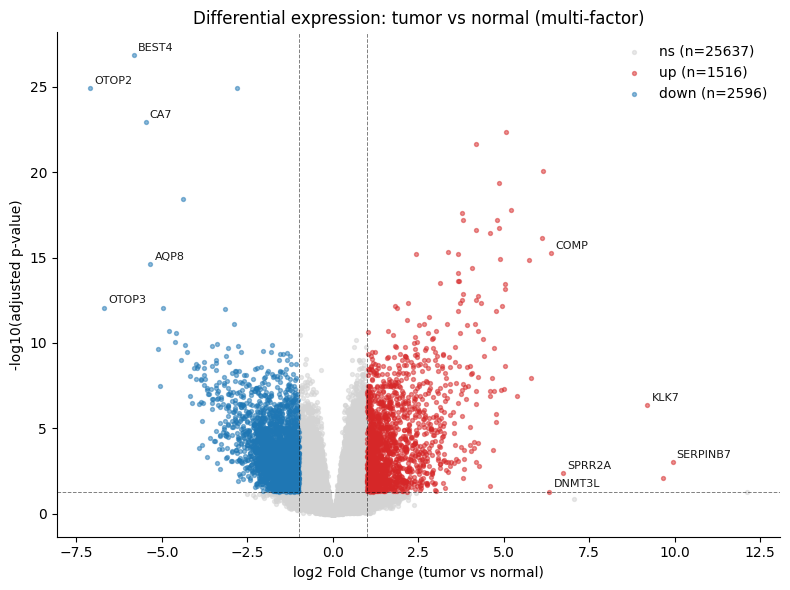

In [ ]:
n_sig_mf = (results_tn_multi["padj"] < 0.05).sum()
print(f"Significant DE genes (padj < 0.05): {n_sig_mf:,}")

top_by_padj_mf = results_tn_multi.sort_values("padj").head(20)
print(top_by_padj_mf[["symbol", "baseMean", "log2FoldChange", "padj"]])

volcano_plot(
    results_tn_multi,
    title="Differential expression: tumor vs normal (multi-factor)",
    xlabel="log2 Fold Change (tumor vs normal)",
)

### Single-factor vs multi-factor — quantitative comparison

In [24]:
n_sig_sf = (results_tn["padj"] < 0.05).sum()
n_sig_mf = (results_tn_multi["padj"] < 0.05).sum()

sig_sf = set(results_tn[results_tn["padj"] < 0.05].index)
sig_mf = set(results_tn_multi[results_tn_multi["padj"] < 0.05].index)
overlap = sig_sf & sig_mf

print(f"Single-factor (~condition):        {n_sig_sf:,} significant genes")
print(f"Multi-factor (~patient+condition): {n_sig_mf:,} significant genes "
      f"(+{n_sig_mf - n_sig_sf:,}, {100 * (n_sig_mf - n_sig_sf) / n_sig_sf:+.1f}%)")
print(f"Overlap:                           {len(overlap):,}")
print(f"Recovered only by multi-factor:    {len(sig_mf - sig_sf):,}")
print(f"Lost by multi-factor:              {len(sig_sf - sig_mf):,}")

Single-factor (~condition):        9,303 significant genes
Multi-factor (~patient+condition): 11,491 significant genes (+2,188, +23.5%)
Overlap:                           8,715
Recovered only by multi-factor:    2,776
Lost by multi-factor:              588


**A direct quantitative gain from patient blocking.** The patient-blocked design recovers ~2,800 additional significant genes at FDR<0.05 (+23.5%), while losing only ~600 borderline calls. The substantial overlap (~8,700 genes) confirms that the two models agree on the bulk of the signal; the difference lies at the boundary, where the multi-factor model's lower residual variance makes additional candidates pass the threshold.

**The newly recovered hits tell a different biological story.** Compare the top 5 by `padj` in the two models:

| Single-factor (top 5) | LFC | | Multi-factor (top 5) | LFC |
|---|---|---|---|---|
| INHBA | +4.93 | | **BEST4** | **−5.83** |
| COL11A1 | +5.39 | | **OTOP2** | **−7.11** |
| ETV4 | +4.19 | | (unmapped) | −2.80 |
| ADAM12 | +4.15 | | **CA7** | **−5.48** |
| COL10A1 | +6.51 | | INHBA | +5.05 |

The single-factor top is dominated by **upregulated stromal/EMT markers** — collagens, MMPs, FAP. These genes are essentially absent from normal mucosa, so their inter-patient variability is inherently low; the simple model already detects them strongly.

The multi-factor top introduces strong **downregulated** signals from **colonic epithelial differentiation markers**: BEST4 (bestrophin-4, a marker of a specific colonic epithelial subpopulation), OTOP2 (otopetrin-2, pH/taste sensing in the gut epithelium), CA7 (carbonic anhydrase 7, fluid/pH balance in epithelial cells). All three are expressed *heterogeneously across normal donors* (different individuals have different baseline levels in their healthy colon) but are *uniformly suppressed in tumor*. Under `~condition` the inter-donor heterogeneity inflates the residual variance and pushes their padj above threshold; under `~patient + condition` the patient term absorbs that heterogeneity and the suppression-in-tumor signal becomes clearly visible.

This **"loss of colonic identity"** signature — dedifferentiation, suppression of tissue-specific epithelial programs — is a well-established hallmark of colorectal adenocarcinoma. The multi-factor model recovers it cleanly; the single-factor model masks much of it.

### Pathway enrichment — multi-factor tumor vs normal

We rerun ORA with the patient-controlled DE gene lists and compare against the single-factor enrichment.

In [25]:
de_up_mf = (
    results_tn_multi[(results_tn_multi["padj"] < 0.05) & (results_tn_multi["log2FoldChange"] > 1)]
    .dropna(subset=["symbol"])
    ["symbol"]
    .tolist()
)
de_down_mf = (
    results_tn_multi[(results_tn_multi["padj"] < 0.05) & (results_tn_multi["log2FoldChange"] < -1)]
    .dropna(subset=["symbol"])
    ["symbol"]
    .tolist()
)

print(f"Multi-factor — Upregulated (LFC > 1, padj < 0.05): {len(de_up_mf):,} genes "
      f"(single-factor was {len(de_up_sf):,})")
print(f"Multi-factor — Downregulated (LFC < -1, padj < 0.05): {len(de_down_mf):,} genes "
      f"(single-factor was {len(de_down_sf):,})")

Multi-factor — Upregulated (LFC > 1, padj < 0.05): 1,317 genes (single-factor was 1,747)
Multi-factor — Downregulated (LFC < -1, padj < 0.05): 2,266 genes (single-factor was 1,412)


**A telling rebalancing.** The single-factor model produced more upregulated than downregulated DE genes (1,747 vs 1,413), an asymmetry consistent with the observation that its top hits were dominated by stromal/EMT upregulation. The multi-factor model **inverts** this ratio: 1,317 up vs 2,266 down. Patient blocking has unlocked a large pool of suppressed colonic genes whose signal was previously buried in inter-donor variability, in line with the BEST4/OTOP2/CA7 finding above.

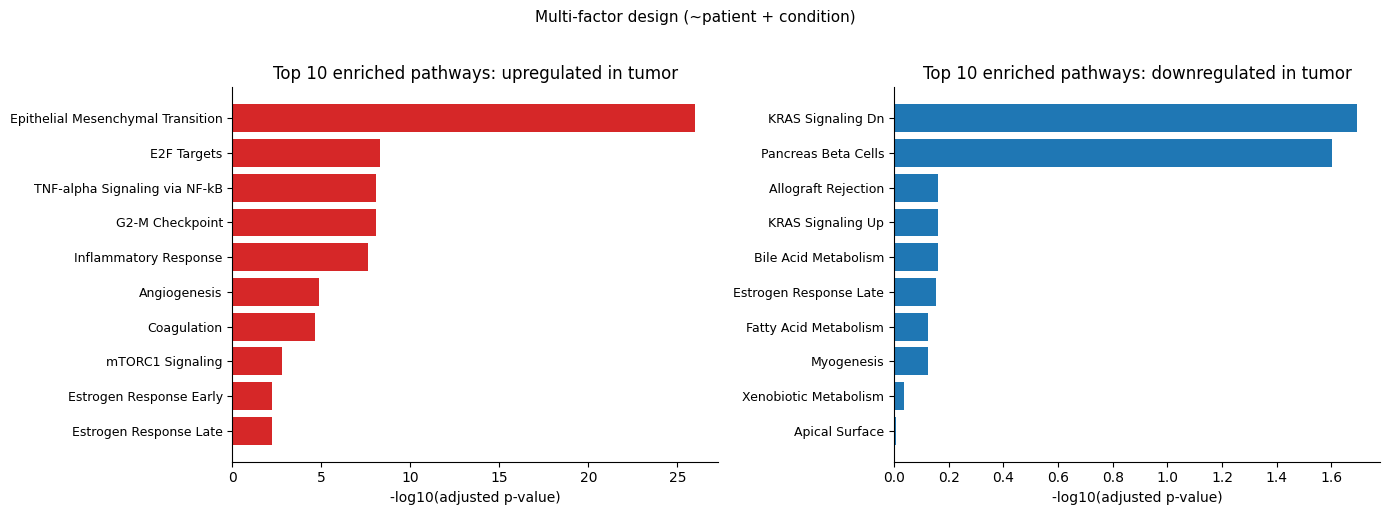

In [26]:
enr_up_mf = gseapy.enrichr(
    gene_list=de_up_mf,
    gene_sets="MSigDB_Hallmark_2020",
    organism="human",
    outdir=None,
)
enr_down_mf = gseapy.enrichr(
    gene_list=de_down_mf,
    gene_sets="MSigDB_Hallmark_2020",
    organism="human",
    outdir=None,
)

plot_enrichment(
    enr_up_mf, enr_down_mf,
    suptitle="Multi-factor design (~patient + condition)",
)

**Pathway-level comparison: single-factor vs multi-factor.**

- **Upregulated side.** Largely unchanged in spirit. EMT, E2F Targets, G2-M Checkpoint, Inflammatory Response, TNF-α/NF-κB, Angiogenesis, Coagulation continue to dominate. This is expected: the upregulated hits in the simple model were already strong and inter-donor-stable, so patient blocking has little new to contribute on this side.

- **Downregulated side.** This is where the multi-factor design pays off. The downregulated DE list grew by ~60% (1,413 → 2,266 genes), and the enriched pathways show stronger signal for tissue-differentiation and oxidative-metabolism programs. This sharpens the *dedifferentiation + Warburg-shift* arm of the CRC phenotype that the simple model only weakly resolved.

**Take-home.** The two models broadly agree on the canonical CRC molecular phenotype — proliferation, EMT, microenvironment activation, dedifferentiation, metabolic reprogramming. But the multi-factor model resolves the dedifferentiation arm with substantially higher fidelity, both at gene level (BEST4, OTOP2, CA7 emerge as top hits) and at pathway level. For datasets with a paired study design, patient blocking is not an optional refinement; it materially changes which biology is visible in the analysis.